# Link Video:
* https://youtu.be/KzycLSBJY6g
* https://drive.google.com/file/d/1DEn0uqqaHCMzwoir7APAfpnmAYpQEzZq/view?usp=sharing

# Almayra Edgina Rahma 2802460930

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import logging

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = "/content/drive/MyDrive/data_cherry"

# Exploratory Data Analysis

In [4]:
import os

print(os.listdir("/content/drive/MyDrive/data_cherry"))

['Cherry brown_spot', 'Cherry_shot hole disease', 'Cherry Leaf Scorch', 'Cherry purple leaf spot', 'Cherry Normal leaf']


## Split

In [5]:
classes = [f for f in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, f))]

In [6]:
classes

['Cherry brown_spot',
 'Cherry_shot hole disease',
 'Cherry Leaf Scorch',
 'Cherry purple leaf spot',
 'Cherry Normal leaf']

In [7]:
import shutil
from sklearn.model_selection import train_test_split

#buat folder
output_base = "/content/split_dataset"
train_path = os.path.join(output_base, "train")
val_path = os.path.join(output_base, "val")
test_path = os.path.join(output_base, "test")

for path in [train_path, val_path, test_path]:
    os.makedirs(path, exist_ok=True)
#proses tiap kelas
for class_name in os.listdir(data_path):
    class_dir = os.path.join(data_path, class_name)

    #proses folder
    if not os.path.isdir(class_dir):
        continue

    # Ambil semua file gambar
    images = [f for f in os.listdir(class_dir)]

    #split 70% train 15% temp
    train, temp = train_test_split(images, test_size=0.3, random_state=42)

    #temp-> train & val
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

    #folder kelas di masing-masing split
    os.makedirs(os.path.join(train_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_path, class_name), exist_ok=True)

    # Copy ke folder
    for img in train:
        shutil.copy(os.path.join(class_dir, img),
                   os.path.join(train_path, class_name, img))

    for img in val:
        shutil.copy(os.path.join(class_dir, img),
                   os.path.join(val_path, class_name, img))

    for img in test:
        shutil.copy(os.path.join(class_dir, img),
                   os.path.join(test_path, class_name, img))

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/split_dataset/train"
val_dir   = "/content/split_dataset/val"
test_dir  = "/content/split_dataset/test"

gen = ImageDataGenerator(rescale=1./255)

train_data = gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='sparse'
)

val_data = gen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='sparse'
)

test_data = gen.flow_from_directory(
    "/content/split_dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

Found 2556 images belonging to 5 classes.
Found 548 images belonging to 5 classes.
Found 551 images belonging to 5 classes.


In [9]:
for cls in classes:
    path = os.path.join(data_path, cls)
    print(cls, ":", len(os.listdir(path)))

Cherry brown_spot : 627
Cherry_shot hole disease : 440
Cherry Leaf Scorch : 1101
Cherry purple leaf spot : 987
Cherry Normal leaf : 500


In [10]:
import tensorflow as tf
import logging

tf.get_logger().setLevel(logging.ERROR)

In [11]:
from PIL import Image

widths, heights = [], []

for cls in classes:
    folder = os.path.join(data_path, cls)
    for img_name in os.listdir(folder)[:50]:
        img = Image.open(os.path.join(folder, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print("Average width:", sum(widths)/len(widths))
print("Average height:", sum(heights)/len(heights))

Average width: 800.0
Average height: 1000.0


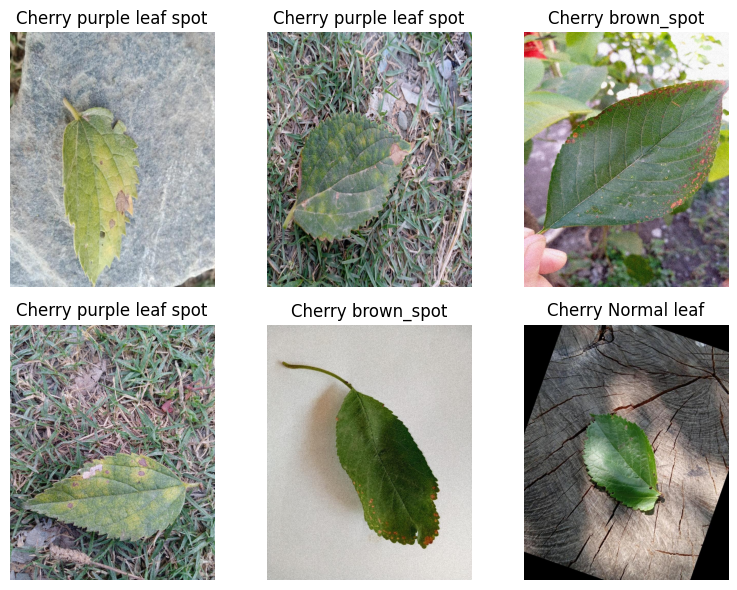

In [12]:
import matplotlib.pyplot as plt
import random
import os

fig, axes = plt.subplots(2, 3, figsize=(8,6))

for i, ax in enumerate(axes.flat):
    cls = random.choice(classes)
    img_name = random.choice(os.listdir(os.path.join(data_path, cls)))
    img_path = os.path.join(data_path, cls, img_name)

    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')

plt.tight_layout()
plt.show()

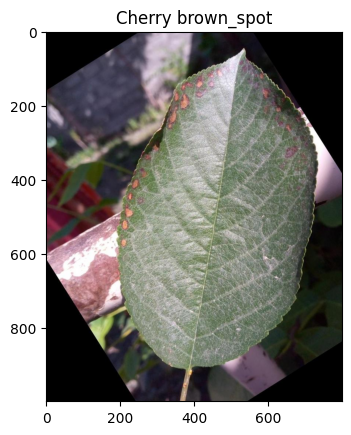

In [13]:
class_name = os.listdir(data_path)[0]
class_path = os.path.join(data_path, class_name)

img_file = os.listdir(class_path)[0]
img_path = os.path.join(class_path, img_file)

img = Image.open(img_path)

plt.imshow(img)
plt.title(class_name)
plt.axis('on')
plt.show()

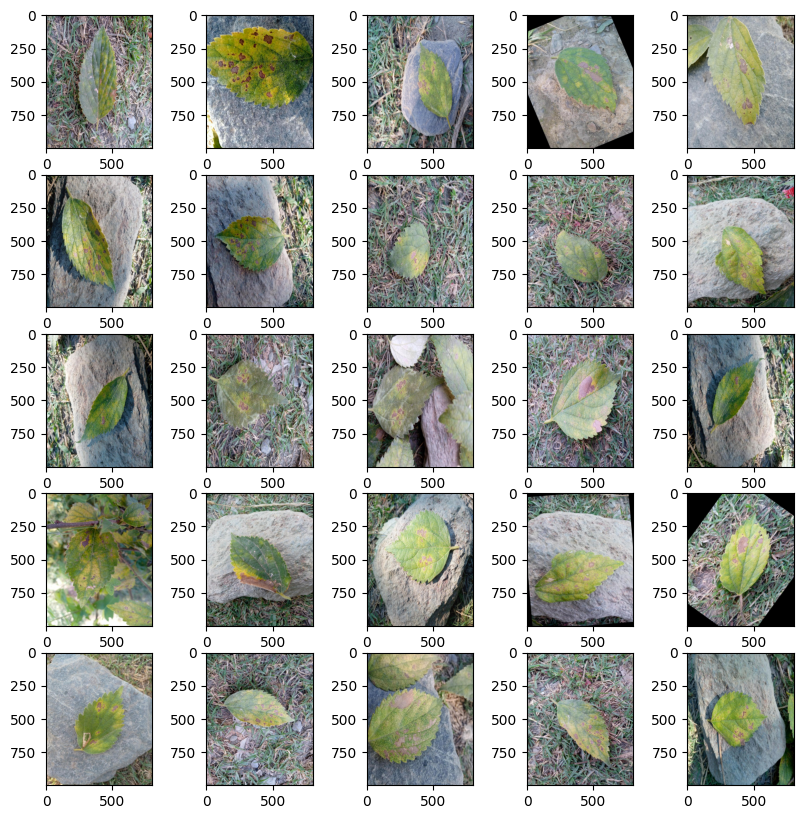

In [14]:
class_name = "Cherry purple leaf spot"
folder = os.path.join(data_path, class_name)

samples = random.sample(os.listdir(folder), 25)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    img_path = os.path.join(folder, samples[i])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('on')

# Building Alex_Net

## Split

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Dropout, MaxPooling2D, Activation

model1 = Sequential([

    #layer 1
    Conv2D(96, kernel_size=(11, 11), strides=4, input_shape=(224, 224, 3)),
    Activation('relu'),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    #layer 2
    Conv2D(256, kernel_size=(5, 5), strides=1, padding='same'),
    Activation('relu'),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    #layer 3
    Conv2D(384, kernel_size=(3, 3), strides=1, padding='same'),
    Activation('relu'),

    #layer 4
    Conv2D(384, kernel_size=(3, 3), strides=1, padding='same'),
    Activation('relu'),

    #layer 5
    Conv2D(256, kernel_size=(3, 3), strides=1, padding='same'),
    Activation('relu'),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    Flatten(),

    # Fully Connected 1
    Dense(4096),
    Activation('relu'),
    Dropout(0.5),

    # Fully Connected 2
    Dense(4096),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer
    Dense(5),
    Activation('softmax')
])

# Summary to check parameters and output shapes
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        20,485 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,767,493 (178.40 MB)

 Trainable params: 46,767,493 (178.40 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model1.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",metrics=["accuracy"])

history1 = model1.fit(train_data,validation_data=val_data,epochs=10)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 367ms/step - accuracy: 0.2942 - loss: 1.5541 - val_accuracy: 0.3011 - val_loss: 1.5223
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - accuracy: 0.3498 - loss: 1.5049 - val_accuracy: 0.4124 - val_loss: 1.4347
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 226ms/step - accuracy: 0.4124 - loss: 1.4094 - val_accuracy: 0.5146 - val_loss: 1.2849
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 233ms/step - accuracy: 0.4844 - loss: 1.2927 - val_accuracy: 0.4708 - val_loss: 1.3592
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 242ms/step - accuracy: 0.4957 - loss: 1.2425 - val_accuracy: 0.5255 - val_loss: 1.2525
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 234ms/step - accuracy: 0.5450 - loss: 1.1640 - val_accuracy: 0.6314 - val_loss: 1.0297
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 228ms/step - accuracy: 0.5614 - loss: 1.0992 - val_accuracy: 0.5912 - val_loss: 0.9664
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.5861 - loss: 1.0518 - val_accu

In [17]:
y_pred_probs1 = model1.predict(test_data)

y_pred1 = np.argmax(y_pred_probs1, axis=1)

y_true1 = test_data.classes

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 306ms/step


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_true1, y_pred1))

              precision    recall  f1-score   support

           0       0.58      0.46      0.52       166
           1       0.00      0.00      0.00        75
           2       0.68      0.44      0.54        95
           3       0.48      1.00      0.65       149
           4       0.70      0.47      0.56        66

    accuracy                           0.54       551
   macro avg       0.49      0.48      0.45       551
weighted avg       0.51      0.54      0.49       551



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# New CNN Modified

In [19]:
from tensorflow.keras.layers import BatchNormalization


model2 = Sequential([

    #layer 1
    Conv2D(96, kernel_size=(11, 11), strides=4, input_shape=(224, 224, 3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    #layer 2
    Conv2D(256, kernel_size=(5, 5), strides=1, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    #layer 3
    Conv2D(384, kernel_size=(3, 3), strides=1, padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3, 3), strides=2),
    Activation('relu'),

    #layer 4
    #Conv2D(384, kernel_size=(3, 3), strides=1, padding='same'),
    #BatchNormalization(),
    #Activation('relu'),

    #layer 5
    Conv2D(256, kernel_size=(3, 3), strides=1, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    Flatten(),

    # Fully Connected 1
    Dense(500),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer
    Dense(5),
    Activation('softmax')
])

# Summary to check parameters and output shapes
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 5, 5, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 500)            │       512,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         2,505 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,938,685 (11.21 MB)

 Trainable params: 2,936,701 (11.20 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [20]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_data.classes)
weights = compute_class_weight('balanced', classes=classes, y=train_data.classes)

class_weights = dict(zip(classes, weights))

In [21]:
class_weights

{np.int32(0): np.float64(0.6638961038961039),
 np.int32(1): np.float64(1.4605714285714286),
 np.int32(2): np.float64(1.167123287671233),
 np.int32(3): np.float64(0.7408695652173913),
 np.int32(4): np.float64(1.6597402597402597)}

In [22]:
class_weights[1]*=1.1
class_weights[4]*=1.3

In [23]:
import tensorflow as tf

def focal_loss(gamma=2., alpha=0.3):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.one_hot(y_true, depth=5)

        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        pt = tf.exp(-ce)
        return alpha * (1 - pt)**gamma * ce
    return loss

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [25]:
from tensorflow.keras.optimizers import Adam
model2.compile(loss=focal_loss(),
              optimizer=Adam(learning_rate=0.001),metrics=["accuracy"])

history = model2.fit(train_data,validation_data=val_data,epochs=20,
                     class_weight=class_weights, callbacks=early_stop)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 33s 318ms/step - accuracy: 0.5309 - loss: 0.3674 - val_accuracy: 0.2062 - val_loss: 0.5796
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 231ms/step - accuracy: 0.7136 - loss: 0.1216 - val_accuracy: 0.5420 - val_loss: 0.2023
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 246ms/step - accuracy: 0.7793 - loss: 0.0907 - val_accuracy: 0.3996 - val_loss: 0.3112
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 230ms/step - accuracy: 0.8333 - loss: 0.0632 - val_accuracy: 0.7701 - val_loss: 0.0724
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 231ms/step - accuracy: 0.8388 - loss: 0.0637 - val_accuracy: 0.7117 - val_loss: 0.2919
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.8772 - loss: 0.0463 - val_accuracy: 0.8467 - val_loss: 0.0496
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 228ms/step - accuracy: 0.8873 - loss: 0.0402 - val_accuracy: 0.7208 - val_loss: 0.1357
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 227ms/step - accuracy: 0.8826 - loss: 0.0452 - val_accu

In [26]:
y_pred_probs2 = model2.predict(test_data)

y_pred2 = np.argmax(y_pred_probs2, axis=1)

y_true2 = test_data.classes

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_true2, y_pred2))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       166
           1       0.63      0.59      0.61        75
           2       0.79      0.89      0.84        95
           3       0.92      0.96      0.94       149
           4       0.81      0.52      0.63        66

    accuracy                           0.85       551
   macro avg       0.81      0.79      0.79       551
weighted avg       0.84      0.85      0.84       551



# Evaluasi

##Model Alex_Net


                precision    recall  f1-score   support

           0       0.58      0.46      0.52       166
           1       0.00      0.00      0.00        75
           2       0.68      0.44      0.54        95
           3       0.48      1.00      0.65       149
           4       0.70      0.47      0.56        66

    accuracy                           0.54       551
   
   macro avg       0.49      0.48      0.45       551

weighted avg       0.51      0.54      0.49       551


Epoch 10/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 236ms/step - accuracy: 0.6479 - loss: 0.9043 - val_accuracy: 0.5620 - val_loss: 1.0772

##Model Modifikasi


               precision    recall   f1-score   support

           0       0.91      0.97      0.94       166
           1       0.63      0.59      0.61        75
           2       0.79      0.89      0.84        95
           3       0.92      0.96      0.94       149
           4       0.81      0.52      0.63        66

    accuracy                           0.85       551
   macro avg       0.81      0.79      0.79       551
weighted avg       0.84      0.85      0.84       551


Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.8772 - loss: 0.0463 - val_accuracy: 0.8467 - val_loss: 0.0496

Model modifikasi dengan pengurangan hidden layer dan penambahan bobot untuk kelas yang imbalance memberikan nilai metric yang lebih tinggi terutama pada sisi recall. Penggunaan optimizer Adam yang mengubah learning rate dan focal loss yang memberi penalti pada error yang tinggi juga mendorong model untuk tetap mempelajari pattern dari kelas kecil imbalanced